# Neural-Linear Bandits — Twitter Customer Support Dataset

In this notebook we train a **Neural-Linear Bandit** contextual bandit on a customer
service environment modeled after the **Twitter Customer Support** characteristics.

From our EDA we know Twitter support conversations are **short and urgent** — customers come in
frustrated (54.7% inbound complaints) and expect quick resolution. 37% of tweets never even get a response.

So our simulator uses: low initial sentiment (0.3), high frustration (0.6), max 10 turns.

### How Neural-Linear Bandits Work
Neural-Linear Bandits combine the **representation power of neural networks** with the
**exploration guarantees of LinUCB**:

1. A **neural network** learns to extract useful features from raw state (feature extractor)
2. The **last hidden layer** output is used as the feature vector
3. A **LinUCB-style linear model** sits on top for action selection with UCB exploration
4. The neural network is periodically retrained on collected experience

This gives us the best of both worlds:
- **Non-linear feature learning** (unlike LinUCB which is purely linear)
- **Principled exploration via UCB** (unlike pure neural approaches)
- **Better generalization** across states (unlike Thompson Sampling's discrete bins)

### Comparison to Other Algorithms
| Algorithm | State Handling | Exploration | Feature Learning |
|---|---|---|---|
| **Thompson Sampling** | Discretized bins (64 contexts) | Beta sampling | None |
| **LinUCB** | Linear features (5D expanded) | UCB bound | Manual (info²) |
| **Neural-Linear** | Neural network features | UCB on learned features | Automatic |

### Metrics We Track
| Metric | What It Tells |
|---|---|
| **Average Reward** | Overall agent performance per episode — higher is better |
| **Resolution Rate** | % of conversations where the issue was solved |
| **Escalation Rate** | % of conversations handed off to a human |
| **Avg Turns** | How long conversations take on average |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import warnings
import sys
warnings.filterwarnings('ignore')

sys.path.insert(0, '..')
from environment import CustomerServiceEnv

print('all imports done!')

all imports done!


## Setting up the Environment

In [2]:
env = CustomerServiceEnv(dataset='twitter')

print(f'Environment: {env.dataset_name}')
print(f'Max turns per conversation: {env.max_turns}')
print(f'Initial sentiment: {env.initial_sentiment}')
print(f'Initial frustration: {env.initial_frustration}')
print(f'Available actions: {env.ACTIONS}')
print(f'State vector size: {env.get_state_size()}')

Environment: Twitter Customer Support
Max turns per conversation: 10
Initial sentiment: 0.3
Initial frustration: 0.6
Available actions: ['ask_info', 'provide_solution', 'empathize', 'escalate', 'close']
State vector size: 4


## Running a random episode

In [3]:
state = env.reset()
total_reward = 0
print('--- Random Agent Episode ---')
print(f'Starting state: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
print()

while not env.done:
    action = random.randint(0, env.NUM_ACTIONS - 1)
    next_state, reward, done, outcome = env.step(action)
    total_reward += reward
    env.render(action)
    state = next_state

print(f'\nTotal reward: {total_reward:.2f}')
print(f'Conversation ended: {outcome}')

--- Random Agent Episode ---
Starting state: sentiment=0.25, frustration=0.82

  Turn  1 | Action: empathize
    Sentiment: 0.35 | Frustration: 0.72 | Info: 0.00
  Turn  2 | Action: ask_info
    Sentiment: 0.30 | Frustration: 0.72 | Info: 0.37
  Turn  3 | Action: ask_info
    Sentiment: 0.25 | Frustration: 0.72 | Info: 0.62
  Turn  4 | Action: escalate
    Sentiment: 0.20 | Frustration: 0.72 | Info: 0.62
    >> Outcome: escalated

Total reward: -2.68
Conversation ended: escalated


## Neural-Linear Bandit Agent

The Neural-Linear Bandit has two components:

### 1. Neural Network (Feature Extractor)
- Takes raw 4D state → hidden layers → outputs a learned feature vector
- Trained periodically on collected (state, action, reward) experience
- Uses a simple feedforward architecture: 4 → 32 → 16 (feature dim)

### 2. Linear UCB (Decision Layer)
- Takes the neural network's last hidden layer output as features
- Maintains per-action ridge regression models (same as LinUCB)
- Selects actions using UCB: `action = argmax(θᵀz + α√(zᵀA⁻¹z))`
- Where `z` = neural network features (instead of raw state)

### Training Schedule
- The neural network is retrained every `retrain_interval` episodes
- Between retrains, the linear layer is updated every step (like LinUCB)
- This amortizes the cost of neural network training

In [4]:
class NeuralLinearAgent:
    
    def __init__(self, n_actions=5, state_dim=4, hidden_dim=32, feature_dim=16, 
                 alpha=1.5, lr=0.01, retrain_interval=500):
        """
        n_actions: number of arms (5 actions)
        state_dim: raw state dimension (4)
        hidden_dim: hidden layer size for the neural network
        feature_dim: output feature dimension from the neural network
        alpha: UCB exploration parameter
        lr: learning rate for neural network training
        retrain_interval: how often to retrain the neural network
        """
        self.n_actions = n_actions
        self.state_dim = state_dim
        self.hidden_dim = hidden_dim
        self.feature_dim = feature_dim
        self.alpha = alpha
        self.lr = lr
        self.retrain_interval = retrain_interval
        
        # --- Neural Network weights (simple 2-layer MLP) ---
        # Layer 1: state_dim -> hidden_dim
        self.W1 = np.random.randn(state_dim, hidden_dim) * np.sqrt(2.0 / state_dim)
        self.b1 = np.zeros(hidden_dim)
        # Layer 2: hidden_dim -> feature_dim
        self.W2 = np.random.randn(hidden_dim, feature_dim) * np.sqrt(2.0 / hidden_dim)
        self.b2 = np.zeros(feature_dim)
        
        # --- LinUCB parameters on top of neural features ---
        self.A = [np.eye(feature_dim) for _ in range(n_actions)]
        self.b_lin = [np.zeros(feature_dim) for _ in range(n_actions)]
        self.A_inv = [np.eye(feature_dim) for _ in range(n_actions)]
        
        # --- Experience buffer for neural network retraining ---
        self.experience = []  # list of (state, action, reward)
        self.episode_count = 0
    
    def _relu(self, x):
        return np.maximum(0, x)
    
    def _forward(self, state):
        """forward pass through neural network to get features"""
        x = np.array(state, dtype=float)
        h = self._relu(x @ self.W1 + self.b1)
        z = self._relu(h @ self.W2 + self.b2)
        # L2 normalize features for stability
        norm = np.linalg.norm(z) + 1e-8
        return z / norm
    
    def choose_action(self, state):
        """use neural features + LinUCB to pick action"""
        z = self._forward(state)
        p_values = np.zeros(self.n_actions)
        
        for a in range(self.n_actions):
            theta = self.A_inv[a] @ self.b_lin[a]
            ucb = self.alpha * np.sqrt(z @ self.A_inv[a] @ z)
            p_values[a] = theta @ z + ucb
        
        return np.argmax(p_values)
    
    def update(self, state, action, reward):
        """update linear layer and store experience"""
        z = self._forward(state)
        # tanh normalization for reward stability
        reward_norm = np.tanh(reward / 2.0)
        
        # update LinUCB layer
        self.A[action] += np.outer(z, z)
        self.b_lin[action] += reward_norm * z
        self.A_inv[action] = np.linalg.inv(self.A[action])
        
        # store experience for neural network retraining
        self.experience.append((np.array(state), action, reward))
    
    def end_episode(self):
        """called at end of each episode — retrain neural net periodically"""
        self.episode_count += 1
        if self.episode_count % self.retrain_interval == 0 and len(self.experience) > 100:
            self._retrain_network()
    
    def _retrain_network(self):
        """retrain the neural network on collected experience"""
        # sample a batch from experience
        batch_size = min(512, len(self.experience))
        indices = np.random.choice(len(self.experience), batch_size, replace=False)
        
        for epoch in range(5):  # few epochs per retrain
            total_loss = 0
            for idx in indices:
                state, action, reward = self.experience[idx]
                reward_norm = np.tanh(reward / 2.0)
                
                # forward pass
                x = np.array(state, dtype=float)
                h_pre = x @ self.W1 + self.b1
                h = self._relu(h_pre)
                z_pre = h @ self.W2 + self.b2
                z = self._relu(z_pre)
                norm = np.linalg.norm(z) + 1e-8
                z_normed = z / norm
                
                # predict reward using current linear weights for this action
                theta = self.A_inv[action] @ self.b_lin[action]
                pred = theta @ z_normed
                
                # loss = (pred - reward_norm)^2
                error = pred - reward_norm
                total_loss += error ** 2
                
                # backprop through linear layer to neural features
                # dL/dz_normed = 2 * error * theta
                dz_normed = 2 * error * theta
                
                # backprop through L2 normalization
                dz = (dz_normed - z_normed * (dz_normed @ z_normed)) / norm
                
                # backprop through ReLU at layer 2
                dz[z_pre <= 0] = 0
                
                # gradients for W2, b2
                dW2 = np.outer(h, dz)
                db2 = dz
                
                # backprop to layer 1
                dh = dz @ self.W2.T
                dh[h_pre <= 0] = 0  # ReLU
                
                # gradients for W1, b1
                dW1 = np.outer(x, dh)
                db1 = dh
                
                # gradient descent update
                self.W1 -= self.lr * np.clip(dW1, -1, 1)
                self.b1 -= self.lr * np.clip(db1, -1, 1)
                self.W2 -= self.lr * np.clip(dW2, -1, 1)
                self.b2 -= self.lr * np.clip(db2, -1, 1)
        
        # IMPORTANT: reset LinUCB parameters after network retrain
        # because the feature space has changed
        self.A = [np.eye(self.feature_dim) for _ in range(self.n_actions)]
        self.b_lin = [np.zeros(self.feature_dim) for _ in range(self.n_actions)]
        self.A_inv = [np.eye(self.feature_dim) for _ in range(self.n_actions)]
        
        # rebuild LinUCB from recent experience using new features
        recent = self.experience[-min(1000, len(self.experience)):]
        for state, action, reward in recent:
            z = self._forward(state)
            reward_norm = np.tanh(reward / 2.0)
            self.A[action] += np.outer(z, z)
            self.b_lin[action] += reward_norm * z
        
        for a in range(self.n_actions):
            self.A_inv[a] = np.linalg.inv(self.A[a])

print('Neural-Linear Bandit agent defined!')
print(f'Architecture: {4} → {32} (ReLU) → {16} (ReLU + L2 norm) → LinUCB')
print(f'Neural network retrained every {500} episodes')
print(f'LinUCB parameters: {16}×{16} matrix + {16}-vector per action')

Neural-Linear Bandit agent defined!
Architecture: 4 → 32 (ReLU) → 16 (ReLU + L2 norm) → LinUCB
Neural network retrained every 500 episodes
LinUCB parameters: 16×16 matrix + 16-vector per action


## Training

We train for 20000 episodes. The neural network retrains every 500 episodes,
while the linear UCB layer updates every step.

**Why this is different from LinUCB**: The neural network learns non-linear 
feature representations automatically — no manual feature expansion needed.
The UCB exploration still applies but on learned features.

In [5]:
agent = NeuralLinearAgent(
    n_actions=env.NUM_ACTIONS, 
    state_dim=env.get_state_size(), 
    hidden_dim=32, 
    feature_dim=16, 
    alpha=1.5,
    lr=0.005,
    retrain_interval=500
)
num_episodes = 20000

all_rewards = []
all_outcomes = []
all_turns = []

for ep in range(num_episodes):
    state = env.reset()
    episode_reward = 0
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        agent.update(state, action, reward)
        episode_reward += reward
        state = next_state
    
    agent.end_episode()
    all_rewards.append(episode_reward)
    all_outcomes.append(outcome)
    all_turns.append(env.turn)
    
    if (ep + 1) % 4000 == 0:
        recent_rewards = all_rewards[-500:]
        recent_resolved = sum(1 for o in all_outcomes[-500:] if o == 'resolved') / 500
        recent_escalated = sum(1 for o in all_outcomes[-500:] if o == 'escalated') / 500
        print(f'Episode {ep+1}/{num_episodes}')
        print(f'  Avg reward (last 500): {np.mean(recent_rewards):.2f}')
        print(f'  Resolution rate: {recent_resolved:.1%}')
        print(f'  Escalation rate: {recent_escalated:.1%}')
        print(f'  Avg turns: {np.mean(all_turns[-500:]):.1f}')
        print()

print('Training complete!')

Episode 4000/20000
  Avg reward (last 500): 1.42
  Resolution rate: 40.6%
  Escalation rate: 5.2%
  Avg turns: 8.4

Episode 8000/20000
  Avg reward (last 500): 0.20
  Resolution rate: 18.0%
  Escalation rate: 5.2%
  Avg turns: 9.4

Episode 12000/20000
  Avg reward (last 500): 0.32
  Resolution rate: 19.0%
  Escalation rate: 4.8%
  Avg turns: 9.5

Episode 16000/20000
  Avg reward (last 500): -0.09
  Resolution rate: 9.4%
  Escalation rate: 6.2%
  Avg turns: 9.5

Episode 20000/20000
  Avg reward (last 500): 0.77
  Resolution rate: 24.6%
  Escalation rate: 4.0%
  Avg turns: 9.3

Training complete!


## Learning Curve

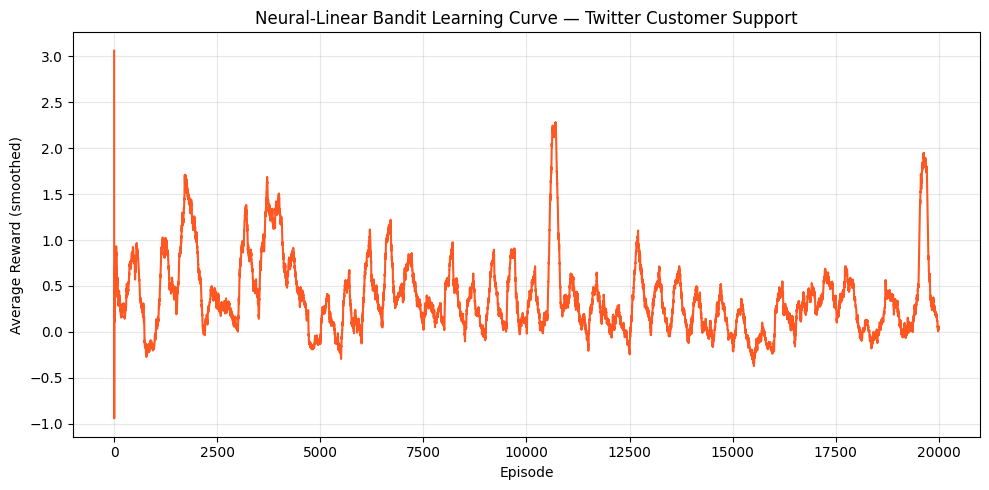

Starting avg reward (first 500): 0.54
Final avg reward (last 500): 0.77


In [6]:
window = 200
smoothed = [np.mean(all_rewards[max(0,i-window):i+1]) for i in range(len(all_rewards))]

plt.figure(figsize=(10, 5))
plt.plot(smoothed, color='#FF5722', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Average Reward (smoothed)')
plt.title('Neural-Linear Bandit Learning Curve — Twitter Customer Support')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Starting avg reward (first 500): {np.mean(all_rewards[:500]):.2f}')
print(f'Final avg reward (last 500): {np.mean(all_rewards[-500:]):.2f}')

## Resolution Rate Over Time

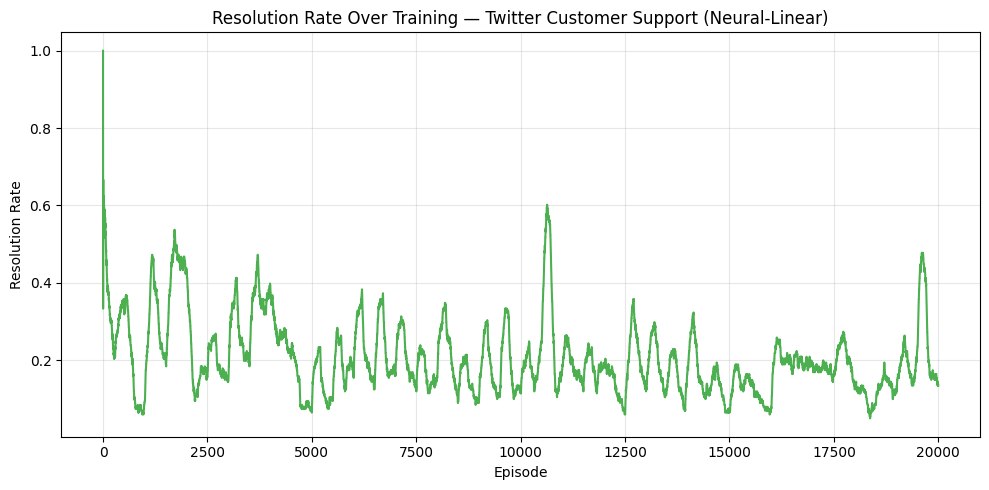

In [7]:
resolution_window = 200
resolution_rates = []
for i in range(len(all_outcomes)):
    start = max(0, i - resolution_window)
    window_outcomes = all_outcomes[start:i+1]
    rate = sum(1 for o in window_outcomes if o == 'resolved') / len(window_outcomes)
    resolution_rates.append(rate)

plt.figure(figsize=(10, 5))
plt.plot(resolution_rates, color='#4CAF50', linewidth=1.5)
plt.xlabel('Episode')
plt.ylabel('Resolution Rate')
plt.title('Resolution Rate Over Training — Twitter Customer Support (Neural-Linear)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## What Actions did the Agent Learn?

Let's examine the agent's learned policy in different customer states. The neural
features should allow the agent to capture more nuanced patterns than LinUCB's 
linear features or Thompson Sampling's discrete bins.

In [8]:
test_scenarios = [
    {'name': 'Angry customer, no info', 'state': [0.2, 0.8, 0.1, 0.1]},
    {'name': 'Calm customer, no info', 'state': [0.7, 0.2, 0.1, 0.1]},
    {'name': 'Angry customer, lots of info', 'state': [0.2, 0.8, 0.8, 0.3]},
    {'name': 'Calm customer, lots of info', 'state': [0.7, 0.2, 0.8, 0.3]},
    {'name': 'Neutral, halfway through', 'state': [0.5, 0.5, 0.5, 0.5]},
]

print('What the agent would do in different situations:')
print('=' * 60)
for scenario in test_scenarios:
    state = np.array(scenario['state'])
    action = agent.choose_action(state)
    action_name = env.ACTIONS[action]
    print(f"\n{scenario['name']}:")
    print(f'  -> {action_name}')
    
    z = agent._forward(state)
    for a in range(env.NUM_ACTIONS):
        theta = agent.A_inv[a] @ agent.b_lin[a]
        ucb = agent.alpha * np.sqrt(z @ agent.A_inv[a] @ z)
        score = theta @ z + ucb
        bar = '#' * max(0, int(score * 5))
        print(f'     {env.ACTIONS[a]:18s} score={score:.3f} {bar}')

What the agent would do in different situations:

Angry customer, no info:
  -> escalate
     ask_info           score=0.332 #
     provide_solution   score=0.679 ###
     empathize          score=0.300 #
     escalate           score=0.684 ###
     close              score=0.484 ##

Calm customer, no info:
  -> escalate
     ask_info           score=0.316 #
     provide_solution   score=0.667 ###
     empathize          score=0.213 #
     escalate           score=0.692 ###
     close              score=0.495 ##

Angry customer, lots of info:
  -> provide_solution
     ask_info           score=0.665 ###
     provide_solution   score=0.957 ####
     empathize          score=0.662 ###
     escalate           score=0.820 ####
     close              score=0.666 ###

Calm customer, lots of info:
  -> provide_solution
     ask_info           score=0.851 ####
     provide_solution   score=1.116 #####
     empathize          score=0.727 ###
     escalate           score=0.958 ####
     close 

## Action Distribution Plot

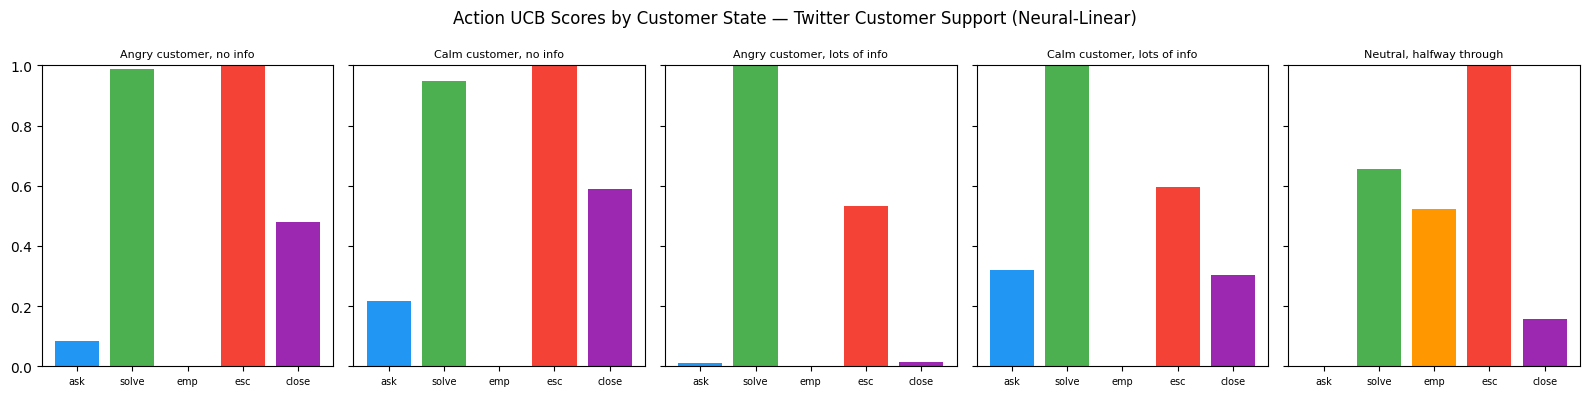

In [9]:
fig, axes = plt.subplots(1, len(test_scenarios), figsize=(16, 4), sharey=True)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#f44336', '#9C27B0']

for idx, scenario in enumerate(test_scenarios):
    state = np.array(scenario['state'])
    z = agent._forward(state)
    scores = np.zeros(env.NUM_ACTIONS)
    for a in range(env.NUM_ACTIONS):
        theta = agent.A_inv[a] @ agent.b_lin[a]
        ucb = agent.alpha * np.sqrt(z @ agent.A_inv[a] @ z)
        scores[a] = theta @ z + ucb
    if scores.max() > scores.min():
        scores_norm = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        scores_norm = np.ones(env.NUM_ACTIONS) / env.NUM_ACTIONS
    
    axes[idx].bar(range(env.NUM_ACTIONS), scores_norm, color=colors)
    axes[idx].set_title(scenario['name'], fontsize=8)
    axes[idx].set_xticks(range(env.NUM_ACTIONS))
    axes[idx].set_xticklabels(['ask', 'solve', 'emp', 'esc', 'close'], fontsize=7)
    axes[idx].set_ylim(0, 1)

fig.suptitle('Action UCB Scores by Customer State — Twitter Customer Support (Neural-Linear)', fontsize=12)
plt.tight_layout()
plt.show()

## Testing the Trained Agent

In [10]:
print('='*60)
print('TESTING THE TRAINED AGENT — 3 sample conversations')
print('='*60)

for test_ep in range(3):
    state = env.reset()
    total_reward = 0
    print(f'\n--- Conversation {test_ep+1} ---')
    print(f'Customer arrives: sentiment={state[0]:.2f}, frustration={state[1]:.2f}')
    
    while not env.done:
        action = agent.choose_action(state)
        next_state, reward, done, outcome = env.step(action)
        total_reward += reward
        action_name = env.ACTIONS[action]
        print(f'  Turn {env.turn}: Agent chose [{action_name}] -> reward={reward:.2f}, sentiment={next_state[0]:.2f}, info={next_state[2]:.2f}')
        state = next_state
    
    print(f'  Result: {outcome} | Total reward: {total_reward:.2f} | Turns: {env.turn}')

TESTING THE TRAINED AGENT — 3 sample conversations

--- Conversation 1 ---
Customer arrives: sentiment=0.26, frustration=0.69
  Turn 1: Agent chose [provide_solution] -> reward=-1.02, sentiment=0.06, info=0.00
  Turn 2: Agent chose [provide_solution] -> reward=-1.02, sentiment=0.00, info=0.00
  Turn 3: Agent chose [provide_solution] -> reward=-1.02, sentiment=0.00, info=0.00
  Turn 4: Agent chose [escalate] -> reward=-3.02, sentiment=0.00, info=0.00
  Result: escalated | Total reward: -6.08 | Turns: 4

--- Conversation 2 ---
Customer arrives: sentiment=0.38, frustration=0.62
  Turn 1: Agent chose [provide_solution] -> reward=-1.02, sentiment=0.18, info=0.00
  Turn 2: Agent chose [provide_solution] -> reward=-1.02, sentiment=0.00, info=0.00
  Turn 3: Agent chose [provide_solution] -> reward=-1.02, sentiment=0.00, info=0.00
  Turn 4: Agent chose [escalate] -> reward=-3.02, sentiment=0.00, info=0.00
  Result: escalated | Total reward: -6.08 | Turns: 4

--- Conversation 3 ---
Customer arri

## Final Summary Stats

In [11]:
test_rewards = []
test_outcomes = {'resolved': 0, 'escalated': 0, 'abandoned': 0}
test_turns = []

for _ in range(500):
    state = env.reset()
    ep_reward = 0
    while not env.done:
        action = agent.choose_action(state)
        state, reward, done, outcome = env.step(action)
        ep_reward += reward
    test_rewards.append(ep_reward)
    test_outcomes[outcome] += 1
    test_turns.append(env.turn)

print('='*50)
print('FINAL EVALUATION (500 test episodes)')
print('='*50)
print(f'Average reward:     {np.mean(test_rewards):.2f}')
print(f'Resolution rate:    {test_outcomes["resolved"]/500:.1%}')
print(f'Escalation rate:    {test_outcomes["escalated"]/500:.1%}')
print(f'Abandonment rate:   {test_outcomes["abandoned"]/500:.1%}')
print(f'Avg conversation:   {np.mean(test_turns):.1f} turns')
print('='*50)

FINAL EVALUATION (500 test episodes)
Average reward:     -2.96
Resolution rate:    33.8%
Escalation rate:    66.2%
Abandonment rate:   0.0%
Avg conversation:   2.9 turns


## Observations

*TODO: Write your observations here after running the notebook.*
- *How does Neural-Linear compare to LinUCB and Thompson Sampling?*
- *Does the neural feature learning help capture non-linear patterns?*
- *Is there a noticeable improvement from neural network retraining steps?*
- *Does the agent learn different strategies for different customer states?*